# Stage 3 — Baseline Model (Zero-Shot IndoBERT + Mean Pooling)
## Project: Optimizing Indonesian Sentence Embeddings for STS

---
**Pipeline Stage:** 3 of 12  
**Notebook:** `03_baseline_model.ipynb`

### Tujuan Stage Ini
Membangun **zero-shot baseline** menggunakan IndoBERT dengan mean pooling **tanpa fine-tuning apapun**. Baseline ini menjadi:
- Titik referensi untuk mengukur improvement SimCSE dan SBERT
- Bukti bahwa pre-trained IndoBERT saja belum cukup untuk STS task
- Target minimum: SimCSE dan SBERT harus beat baseline ini

### Cell Structure
```
3.0   Bootstrap
3.1   Build SentenceTransformer dari IndoBERT
3.2   Encode val set -> simpan embeddings
3.3   Evaluasi: Pearson & Spearman correlation
3.4   Evaluasi per kategori (Low/Mid/High)
3.5   Qualitative analysis: nearest neighbor
3.6   Simpan baseline model ke Drive
3.7   Simpan hasil evaluasi ke JSON
3.8   Sanity check
```

### Output
```
models/baseline/                    <- model checkpoint
embeddings/baseline_val_embeddings.npy
embeddings/baseline_test_embeddings.npy
evaluation/baseline_results.json
experiments/baseline/eval_log.csv
```
---

In [2]:
# ============================================================
# CELL 3.0 - Bootstrap
# ============================================================

import sys, os
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

PROJECT_ROOT = "/content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings"
sys.path.insert(0, PROJECT_ROOT)

from project_config import PATHS, HF_CACHE_DIR

os.environ["HF_HOME"]                = HF_CACHE_DIR
os.environ["TRANSFORMERS_CACHE"]     = HF_CACHE_DIR
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# HF Login
from google.colab import userdata
try:
    from huggingface_hub import login
    login(token=userdata.get('HF_TOKEN'), add_to_git_credential=False)
    print("[OK] HF login berhasil.")
except Exception as e:
    print(f"[WARN] HF login: {e}")

import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[OK] Device : {DEVICE}")
if DEVICE == "cuda":
    print(f"     GPU    : {torch.cuda.get_device_name(0)}")
    print(f"     VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"[OK] Project: {PROJECT_ROOT}")

Mounted at /content/drive
[OK] HF login berhasil.
[OK] Device : cuda
     GPU    : Tesla T4
     VRAM   : 15.6 GB
[OK] Project: /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings


In [3]:
# ============================================================
# CELL 3.0b - Imports
# ============================================================

!pip install -q sentence-transformers transformers

import numpy as np
import pandas as pd
import json
import time
from pathlib import Path
from scipy.stats import pearsonr, spearmanr

from sentence_transformers import SentenceTransformer, models, util
from src.data_loader import load_splits, print_split_summary

print("[OK] Imports selesai.")

[OK] Imports selesai.


In [4]:
# ============================================================
# CELL 3.1 - Build SentenceTransformer dari IndoBERT
# ============================================================
# Arsitektur:
#   IndoBERT (indobenchmark/indobert-base-p1)
#   + Mean Pooling over token embeddings
#   = 768-dimensional sentence embedding
#
# ZERO-SHOT: tidak ada fine-tuning, weights IndoBERT as-is
# dari pre-training pada corpus Indonesian Wikipedia + news

print("[INFO] Building Zero-Shot Baseline SentenceTransformer...")
print("       (Download ~440MB jika belum di cache)\n")

# -- Module 1: IndoBERT Transformer encoder
word_embedding_model = models.Transformer(
    model_name_or_path="indobenchmark/indobert-base-p1",
    max_seq_length=128,     # 128 tokens covers ~95% Indonesian sentences
    do_lower_case=False     # IndoBERT case-sensitive
)

# -- Module 2: Mean pooling
# Mean pooling = rata-rata semua token embeddings (termasuk padding di-mask)
# Lebih baik dari CLS token untuk sentence similarity tasks
pooling_model = models.Pooling(
    word_embedding_model.get_word_embedding_dimension(),  # 768
    pooling_mode_mean_tokens=True,
    pooling_mode_cls_token=False,
    pooling_mode_max_tokens=False
)

# -- Gabungkan menjadi SentenceTransformer
baseline_model = SentenceTransformer(
    modules=[word_embedding_model, pooling_model],
    device=DEVICE
)

print(f"[OK] Model berhasil dibangun.")
print(f"     Base model      : indobenchmark/indobert-base-p1")
print(f"     Pooling         : Mean pooling")
print(f"     Embedding dim   : {word_embedding_model.get_word_embedding_dimension()}")
print(f"     Max seq length  : 128 tokens")
print(f"     Device          : {DEVICE}")
print(f"     Fine-tuned      : NO (zero-shot)")

# -- Quick sanity test
test_sents = [
    "Saya suka makan nasi goreng.",
    "Nasi goreng adalah makanan kesukaanku.",
    "Presiden sedang berpidato di istana negara."
]
test_emb = baseline_model.encode(test_sents, normalize_embeddings=True)
sim_12 = util.cos_sim(test_emb[0], test_emb[1]).item()
sim_13 = util.cos_sim(test_emb[0], test_emb[2]).item()
print(f"\n  Quick test cosine similarity:")
print(f"    '{test_sents[0][:40]}' vs '{test_sents[1][:40]}'")
print(f"    sim = {sim_12:.4f}  (diharapkan: tinggi ~0.7-0.9)")
print(f"\n    '{test_sents[0][:40]}' vs '{test_sents[2][:40]}'")
print(f"    sim = {sim_13:.4f}  (diharapkan: rendah ~0.3-0.6)")

[INFO] Building Zero-Shot Baseline SentenceTransformer...
       (Download ~440MB jika belum di cache)



config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[OK] Model berhasil dibangun.
     Base model      : indobenchmark/indobert-base-p1
     Pooling         : Mean pooling
     Embedding dim   : 768
     Max seq length  : 128 tokens
     Device          : cuda
     Fine-tuned      : NO (zero-shot)

  Quick test cosine similarity:
    'Saya suka makan nasi goreng.' vs 'Nasi goreng adalah makanan kesukaanku.'
    sim = 0.7566  (diharapkan: tinggi ~0.7-0.9)

    'Saya suka makan nasi goreng.' vs 'Presiden sedang berpidato di istana nega'
    sim = 0.5715  (diharapkan: rendah ~0.3-0.6)


In [5]:
# ============================================================
# CELL 3.2 - Load Dataset & Encode Embeddings
# ============================================================
# Encode val dan test set, simpan embeddings ke Drive.
# Embeddings disimpan agar tidak perlu re-encode di stage lain.
#
# Estimasi waktu encoding:
#   val  (2994 pairs x2 = ~6000 sentences): ~30 detik GPU / ~3 menit CPU
#   test (1372 pairs x2 = ~2744 sentences): ~15 detik GPU / ~1.5 menit CPU

print("[INFO] Loading dataset splits...")
data = load_splits(PATHS['splits'])
print_split_summary(data)

df_val  = data['val']
df_test = data['test']

EMB_DIR = PATHS['embeddings']
EMB_DIR.mkdir(parents=True, exist_ok=True)

def encode_split(df, split_name, model, save_dir):
    """
    Encode semua sentence pairs dalam split.
    Simpan embeddings sebagai .npy untuk reuse di stage lain.

    Returns:
        emb_s1, emb_s2  : np.ndarray shape (N, 768)
        scores          : np.ndarray shape (N,)
    """
    print(f"\n  Encoding {split_name} ({len(df):,} pairs)...")
    s1_list = df['sentence1'].tolist()
    s2_list = df['sentence2'].tolist()
    scores  = df['score'].values

    t0 = time.time()
    emb_s1 = model.encode(
        s1_list,
        batch_size=128,
        normalize_embeddings=True,
        show_progress_bar=True,
        convert_to_numpy=True
    )
    emb_s2 = model.encode(
        s2_list,
        batch_size=128,
        normalize_embeddings=True,
        show_progress_bar=True,
        convert_to_numpy=True
    )
    elapsed = time.time() - t0

    # Simpan ke Drive
    np.save(save_dir / f"baseline_{split_name}_emb_s1.npy", emb_s1)
    np.save(save_dir / f"baseline_{split_name}_emb_s2.npy", emb_s2)
    np.save(save_dir / f"baseline_{split_name}_scores.npy",  scores)

    print(f"  [OK] Shape  : {emb_s1.shape}  (normalized L2)")
    print(f"       Elapsed : {elapsed:.1f}s")
    print(f"       Saved   : baseline_{split_name}_emb_s1/s2.npy")
    return emb_s1, emb_s2, scores

emb_val_s1,  emb_val_s2,  scores_val  = encode_split(df_val,  'val',  baseline_model, EMB_DIR)
emb_test_s1, emb_test_s2, scores_test = encode_split(df_test, 'test', baseline_model, EMB_DIR)

[INFO] Loading dataset splits...
[OK] train: 5,696 pairs  score [0.000 - 1.000]
[OK] val: 2,994 pairs  score [0.000 - 1.000]
[OK] test: 1,372 pairs  score [0.000 - 1.000]

  DATASET SPLIT SUMMARY

  TRAIN : 5,696 pairs
    Score: mean=0.540  std=0.293
    Low=1,756(31%)  Mid=2,549(45%)  High=1,391(24%)

  VAL   : 2,994 pairs
    Score: mean=0.472  std=0.300
    Low=1,196(40%)  Mid=1,274(43%)  High=524(18%)

  TEST  : 1,372 pairs
    Score: mean=0.521  std=0.305
    Low=439(32%)  Mid=599(44%)  High=334(24%)

  TOTAL: 10,062 pairs

  Encoding val (2,994 pairs)...


Batches:   0%|          | 0/24 [00:00<?, ?it/s]

Batches:   0%|          | 0/24 [00:00<?, ?it/s]

  [OK] Shape  : (2994, 768)  (normalized L2)
       Elapsed : 9.8s
       Saved   : baseline_val_emb_s1/s2.npy

  Encoding test (1,372 pairs)...


Batches:   0%|          | 0/11 [00:00<?, ?it/s]

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

  [OK] Shape  : (1372, 768)  (normalized L2)
       Elapsed : 3.4s
       Saved   : baseline_test_emb_s1/s2.npy


In [6]:
# ============================================================
# CELL 3.3 - Evaluasi: Pearson & Spearman Correlation
# ============================================================
# Pipeline evaluasi sesuai blueprint:
#   1. Cosine similarity antara emb_s1 dan emb_s2
#   2. Pearson correlation: linear relationship
#   3. Spearman correlation: rank-order relationship (metric utama)
#
# Catatan: score sudah dinormalisasi 0-1, cosine sim juga 0-1
# (karena embeddings sudah L2-normalized, cosine = dot product)

def compute_sts_metrics(emb_s1, emb_s2, gold_scores, split_name):
    """
    Hitung Pearson dan Spearman correlation untuk STS evaluation.

    Args:
        emb_s1, emb_s2  : embeddings yang sudah L2-normalized
        gold_scores     : human annotation scores (0-1)
        split_name      : nama split untuk display

    Returns:
        dict dengan pearson, spearman, dan predicted scores
    """
    # Cosine similarity (= dot product karena sudah normalized)
    cos_scores = np.sum(emb_s1 * emb_s2, axis=1)  # shape (N,)

    # Pearson: korelasi linear
    pearson_r,  pearson_p  = pearsonr(gold_scores, cos_scores)

    # Spearman: korelasi rank (lebih robust, metric utama di STS)
    spearman_r, spearman_p = spearmanr(gold_scores, cos_scores)

    results = {
        'split'      : split_name,
        'n_pairs'    : len(gold_scores),
        'pearson'    : round(float(pearson_r),  4),
        'pearson_p'  : round(float(pearson_p),  6),
        'spearman'   : round(float(spearman_r), 4),
        'spearman_p' : round(float(spearman_p), 6),
        'cos_mean'   : round(float(cos_scores.mean()), 4),
        'cos_std'    : round(float(cos_scores.std()),  4),
    }

    print(f"\n  {'='*45}")
    print(f"  Baseline Evaluation — {split_name.upper()}")
    print(f"  {'='*45}")
    print(f"  N pairs         : {results['n_pairs']:,}")
    print(f"  Pearson  (r)    : {results['pearson']:.4f}  (p={results['pearson_p']:.2e})")
    print(f"  Spearman (rho)  : {results['spearman']:.4f}  (p={results['spearman_p']:.2e})")
    print(f"  Cos sim mean    : {results['cos_mean']:.4f}  std={results['cos_std']:.4f}")

    # Interpretasi
    sp = results['spearman']
    if sp >= 0.80:   interp = "Excellent"
    elif sp >= 0.70: interp = "Good"
    elif sp >= 0.60: interp = "Moderate"
    elif sp >= 0.50: interp = "Fair"
    else:             interp = "Poor — expected for zero-shot baseline"
    print(f"  Interpretation  : {interp}")

    results['cos_scores'] = cos_scores
    return results


print("[INFO] Computing STS metrics...")
val_results  = compute_sts_metrics(emb_val_s1,  emb_val_s2,  scores_val,  'val')
test_results = compute_sts_metrics(emb_test_s1, emb_test_s2, scores_test, 'test')

print(f"\n  {'='*45}")
print(f"  SUMMARY — BASELINE (Zero-Shot)")
print(f"  {'='*45}")
print(f"  Val  Spearman : {val_results['spearman']:.4f}")
print(f"  Test Spearman : {test_results['spearman']:.4f}")
print(f"  Target        : >= 0.80 (after fine-tuning)")
print(f"  Gap to target : {0.80 - test_results['spearman']:+.4f}")

[INFO] Computing STS metrics...

  Baseline Evaluation — VAL
  N pairs         : 2,994
  Pearson  (r)    : 0.5594  (p=0.00e+00)
  Spearman (rho)  : 0.5625  (p=0.00e+00)
  Cos sim mean    : 0.7386  std=0.1414
  Interpretation  : Fair

  Baseline Evaluation — TEST
  N pairs         : 1,372
  Pearson  (r)    : 0.4597  (p=0.00e+00)
  Spearman (rho)  : 0.4653  (p=0.00e+00)
  Cos sim mean    : 0.7808  std=0.1161
  Interpretation  : Poor — expected for zero-shot baseline

  SUMMARY — BASELINE (Zero-Shot)
  Val  Spearman : 0.5625
  Test Spearman : 0.4653
  Target        : >= 0.80 (after fine-tuning)
  Gap to target : +0.3347


[INFO] Per-category evaluation...

  Per-category Spearman — VAL
  Category            N    Spearman     Pearson
  ---------------------------------------------
  Low (0-2)        1196      0.2998      0.3018
  Mid (2-4)        1274      0.2081      0.2170
  High (4-5)        524      0.2595      0.2481

  Per-category Spearman — TEST
  Category            N    Spearman     Pearson
  ---------------------------------------------
  Low (0-2)         439      0.3848      0.3621
  Mid (2-4)         599      0.1733      0.1658
  High (4-5)        334      0.2367      0.2064


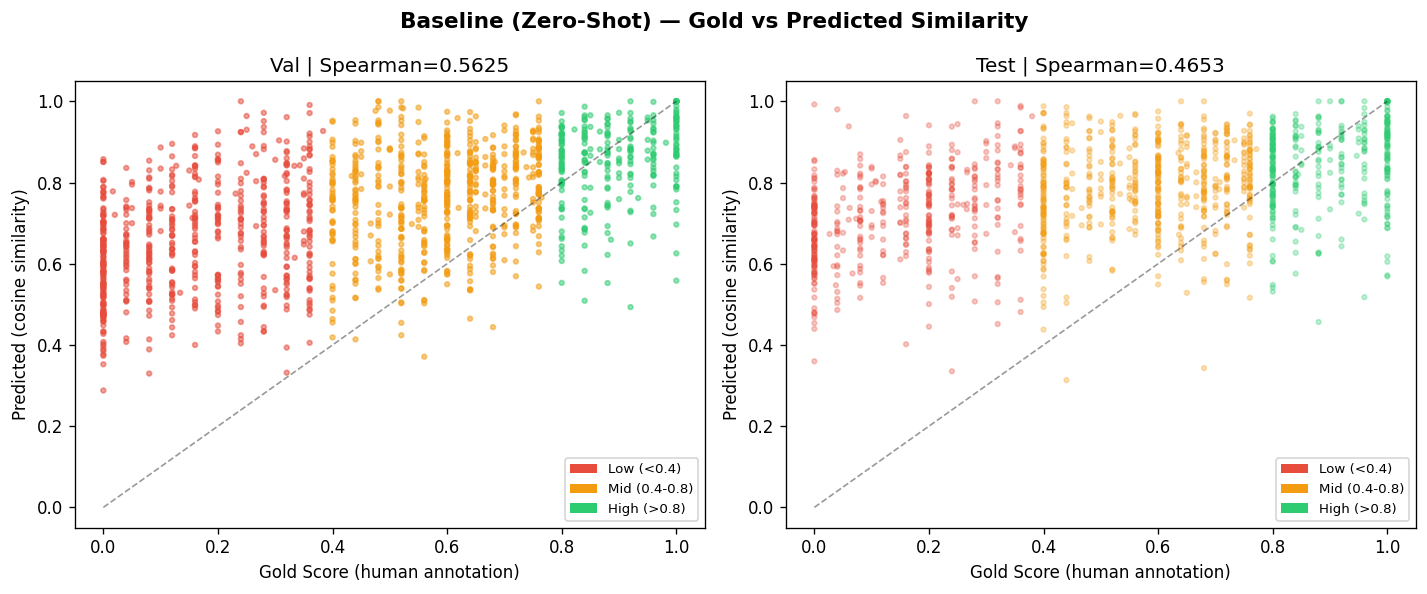

[OK] Plot tersimpan: /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/evaluation/baseline_scatter.png


In [7]:
# ============================================================
# CELL 3.4 - Evaluasi per Kategori (Low / Mid / High)
# ============================================================
# Analisis per kategori similarity mengungkap:
#   - Apakah model lemah di low similarity (false positive)?
#   - Apakah model lemah di high similarity (false negative)?
# Insight ini penting untuk memilih loss function di Stage 7-9.

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

def evaluate_by_category(df, cos_scores, split_name):
    """
    Evaluasi Spearman correlation per kategori similarity:
      Low  : score < 0.4  (0-2 on 0-5 scale)
      Mid  : 0.4 <= score < 0.8
      High : score >= 0.8 (4-5 on 0-5 scale)
    """
    gold = df['score'].values
    cats = {
        'Low (0-2)'  : gold < 0.4,
        'Mid (2-4)'  : (gold >= 0.4) & (gold < 0.8),
        'High (4-5)' : gold >= 0.8
    }

    print(f"\n  Per-category Spearman — {split_name.upper()}")
    print(f"  {'Category':<14} {'N':>6}  {'Spearman':>10}  {'Pearson':>10}")
    print(f"  {'-'*45}")

    cat_results = {}
    for cat_name, mask in cats.items():
        if mask.sum() < 5:
            print(f"  {cat_name:<14} {'<5 samples — skip':>28}")
            continue
        g_sub = gold[mask]
        c_sub = cos_scores[mask]
        sp = spearmanr(g_sub, c_sub).statistic
        pe = pearsonr(g_sub, c_sub).statistic
        n  = mask.sum()
        print(f"  {cat_name:<14} {n:>6}  {sp:>10.4f}  {pe:>10.4f}")
        cat_results[cat_name] = {'n': int(n), 'spearman': round(float(sp),4),
                                  'pearson': round(float(pe),4)}
    return cat_results

print("[INFO] Per-category evaluation...")
val_cat  = evaluate_by_category(df_val,  val_results['cos_scores'],  'val')
test_cat = evaluate_by_category(df_test, test_results['cos_scores'], 'test')

# -- Visualisasi: scatter plot gold vs predicted
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Baseline (Zero-Shot) — Gold vs Predicted Similarity',
             fontsize=13, fontweight='bold')

for ax, (df_sp, cos_sp, gold_sp, sp_name) in zip(axes, [
    (df_val,  val_results['cos_scores'],  scores_val,  'Val'),
    (df_test, test_results['cos_scores'], scores_test, 'Test')
]):
    colors = ['#e74c3c' if g < 0.4 else ('#f39c12' if g < 0.8 else '#2ecc71')
              for g in gold_sp]
    ax.scatter(gold_sp, cos_sp, c=colors, alpha=0.3, s=8)

    # Reference line (perfect prediction)
    ax.plot([0,1],[0,1], 'k--', alpha=0.4, linewidth=1, label='Perfect')

    sp_val = spearmanr(gold_sp, cos_sp).statistic
    ax.set_xlabel('Gold Score (human annotation)')
    ax.set_ylabel('Predicted (cosine similarity)')
    ax.set_title(f'{sp_name} | Spearman={sp_val:.4f}')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#e74c3c', label='Low (<0.4)'),
        Patch(facecolor='#f39c12', label='Mid (0.4-0.8)'),
        Patch(facecolor='#2ecc71', label='High (>0.8)'),
    ]
    ax.legend(handles=legend_elements, fontsize=8)

plt.tight_layout()
fig_path = PATHS['evaluation'] / 'baseline_scatter.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"[OK] Plot tersimpan: {fig_path}")

In [8]:
# ============================================================
# CELL 3.5 - Qualitative Analysis: Nearest Neighbor Retrieval
# ============================================================
# Untuk 5 seed sentences, retrieve top-5 most similar sentences
# dari val set. Analisis kualitatif ini mengungkap:
#   - Apakah model bisa retrieve semantically similar sentences?
#   - Apakah ada false positives (lexically similar, semantically different)?

def nearest_neighbor_analysis(model, query_sentences, corpus_df,
                               top_k=5, model_name='Baseline'):
    """
    Untuk setiap query, retrieve top-k nearest neighbors
    dari corpus (semua sentence1 di val set).
    """
    corpus = corpus_df['sentence1'].tolist()

    print(f"  Encoding corpus ({len(corpus):,} sentences)...")
    corpus_emb = model.encode(
        corpus,
        batch_size=128,
        normalize_embeddings=True,
        show_progress_bar=False,
        convert_to_numpy=True
    )

    print(f"  Encoding queries ({len(query_sentences)} sentences)...")
    query_emb = model.encode(
        query_sentences,
        normalize_embeddings=True,
        convert_to_numpy=True
    )

    print(f"\n{'='*60}")
    print(f"  NEAREST NEIGHBOR ANALYSIS — {model_name}")
    print(f"{'='*60}")

    for i, (query, q_emb) in enumerate(zip(query_sentences, query_emb)):
        # Cosine similarities dengan seluruh corpus
        cos_sims = np.dot(corpus_emb, q_emb)  # shape (N,)
        top_idx  = np.argsort(cos_sims)[::-1][:top_k]

        print(f"\n  Query {i+1}: {query}")
        print(f"  {'─'*55}")
        for rank, idx in enumerate(top_idx, 1):
            sim  = cos_sims[idx]
            sent = corpus[idx]
            print(f"  [{rank}] sim={sim:.4f}  {sent[:65]}")


# Seed sentences — campuran topik berbeda untuk test retrieval
SEED_SENTENCES = [
    "Seorang pria sedang bermain gitar di jalanan.",
    "Harga bahan bakar minyak naik signifikan bulan ini.",
    "Anak-anak bermain bola di lapangan sekolah.",
    "Dokter memeriksa pasien di rumah sakit.",
    "Tim sepak bola Indonesia berhasil memenangkan pertandingan.",
]

nearest_neighbor_analysis(
    baseline_model,
    SEED_SENTENCES,
    df_val,
    top_k=5,
    model_name='Zero-Shot Baseline'
)

  Encoding corpus (2,994 sentences)...
  Encoding queries (5 sentences)...

  NEAREST NEIGHBOR ANALYSIS — Zero-Shot Baseline

  Query 1: Seorang pria sedang bermain gitar di jalanan.
  ───────────────────────────────────────────────────────
  [1] sim=0.8867  Seorang pria bermain biola di tengah hujan.
  [2] sim=0.8867  Seorang pria bermain biola di tengah hujan.
  [3] sim=0.8843  Seorang pria duduk di lantai bermain gitar.
  [4] sim=0.8843  Seorang pria duduk di lantai bermain gitar.
  [5] sim=0.8699  Seorang pria bermain gitar dan bernyanyi di panggung.

  Query 2: Harga bahan bakar minyak naik signifikan bulan ini.
  ───────────────────────────────────────────────────────
  [1] sim=0.6450  Pasar Amerika Utara telah disalurkan dalam perdagangan tanpa arah
  [2] sim=0.6450  Pasar Amerika Utara telah disalurkan dalam perdagangan tanpa arah
  [3] sim=0.6309  Iran mengancam akan memicu perang harga minyak
  [4] sim=0.6309  Iran mengancam akan memicu perang harga minyak
  [5] sim=0.6289  N

In [9]:
# ============================================================
# CELL 3.6 - Simpan Baseline Model ke Drive
# ============================================================
# Simpan model agar:
#   1. Bisa di-load ulang tanpa re-download IndoBERT
#   2. Sebagai checkpoint perbandingan di Stage 10

MODEL_SAVE_PATH = PATHS['baseline_model']
MODEL_SAVE_PATH.mkdir(parents=True, exist_ok=True)

print(f"[INFO] Saving baseline model to Drive...")
print(f"       Path: {MODEL_SAVE_PATH}")

baseline_model.save(str(MODEL_SAVE_PATH))

# Verifikasi: coba load ulang
print("[INFO] Verifikasi: loading model dari Drive...")
loaded_model = SentenceTransformer(str(MODEL_SAVE_PATH), device=DEVICE)
test_emb_check = loaded_model.encode(
    ["Saya suka makan nasi goreng."],
    normalize_embeddings=True
)
print(f"[OK] Model saved & verified.")
print(f"     Embedding dim : {test_emb_check.shape[1]}")

# Hitung ukuran folder model
import os
total_size = sum(
    os.path.getsize(os.path.join(dp, f))
    for dp, _, files in os.walk(MODEL_SAVE_PATH)
    for f in files
) / 1e6
print(f"     Model size    : {total_size:.1f} MB")
print(f"     Save path     : {MODEL_SAVE_PATH}")

[INFO] Saving baseline model to Drive...
       Path: /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/models/baseline


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[INFO] Verifikasi: loading model dari Drive...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[OK] Model saved & verified.
     Embedding dim : 768
     Model size    : 498.5 MB
     Save path     : /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/models/baseline


In [10]:
# ============================================================
# CELL 3.7 - Simpan Hasil Evaluasi ke JSON & CSV
# ============================================================
# Hasil evaluasi disimpan dalam dua format:
#   1. JSON: machine-readable, di-load di Stage 10 untuk comparison table
#   2. CSV : human-readable experiment log

import datetime

baseline_eval = {
    'model_name'   : 'baseline_zero_shot',
    'base_model'   : 'indobenchmark/indobert-base-p1',
    'fine_tuned'   : False,
    'pooling'      : 'mean',
    'timestamp'    : datetime.datetime.now().isoformat(),
    'val': {
        'pearson'       : val_results['pearson'],
        'spearman'      : val_results['spearman'],
        'n_pairs'       : val_results['n_pairs'],
        'by_category'   : val_cat,
    },
    'test': {
        'pearson'       : test_results['pearson'],
        'spearman'      : test_results['spearman'],
        'n_pairs'       : test_results['n_pairs'],
        'by_category'   : test_cat,
    },
    'model_path'   : str(PATHS['baseline_model']),
}

# -- Simpan JSON
json_path = PATHS['evaluation'] / 'baseline_results.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(baseline_eval, f, indent=2, ensure_ascii=False)
print(f"[OK] Saved: {json_path}")

# -- Simpan experiment log CSV
PATHS['baseline_exp'].mkdir(parents=True, exist_ok=True)
log_path = PATHS['baseline_exp'] / 'eval_log.csv'
log_df = pd.DataFrame([{
    'model'          : 'baseline_zero_shot',
    'val_pearson'    : val_results['pearson'],
    'val_spearman'   : val_results['spearman'],
    'test_pearson'   : test_results['pearson'],
    'test_spearman'  : test_results['spearman'],
    'timestamp'      : datetime.datetime.now().isoformat(),
}])
log_df.to_csv(log_path, index=False)
print(f"[OK] Saved: {log_path}")

# -- Print final summary
print(f"\n{'='*50}")
print(f"  BASELINE EVALUATION RESULTS")
print(f"{'='*50}")
print(f"  Model   : Zero-Shot IndoBERT + Mean Pooling")
print(f"  {'─'*46}")
print(f"  {'Split':<8} {'Pearson':>10} {'Spearman':>10}")
print(f"  {'─'*46}")
print(f"  {'Val':<8} {val_results['pearson']:>10.4f} {val_results['spearman']:>10.4f}")
print(f"  {'Test':<8} {test_results['pearson']:>10.4f} {test_results['spearman']:>10.4f}")
print(f"  {'─'*46}")
print(f"  Target Spearman (after fine-tuning) : >= 0.80")
print(f"  Gap (test Spearman -> 0.80)         : {0.80 - test_results['spearman']:+.4f}")
print(f"{'='*50}")

[OK] Saved: /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/evaluation/baseline_results.json
[OK] Saved: /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/experiments/baseline/eval_log.csv

  BASELINE EVALUATION RESULTS
  Model   : Zero-Shot IndoBERT + Mean Pooling
  ──────────────────────────────────────────────
  Split       Pearson   Spearman
  ──────────────────────────────────────────────
  Val          0.5594     0.5625
  Test         0.4597     0.4653
  ──────────────────────────────────────────────
  Target Spearman (after fine-tuning) : >= 0.80
  Gap (test Spearman -> 0.80)         : +0.3347


In [11]:
# ============================================================
# CELL 3.8 - Sanity Check
# ============================================================

print("[INFO] Sanity check output Stage 3...\n")
checks = []

# [1] Model saved
try:
    config_path = PATHS['baseline_model'] / 'config.json'
    assert config_path.exists()
    checks.append(('models/baseline/', True, 'model files exist'))
except Exception as e:
    checks.append(('models/baseline/', False, str(e)))

# [2] Embeddings saved
for fname in ['baseline_val_emb_s1.npy', 'baseline_val_emb_s2.npy',
              'baseline_test_emb_s1.npy', 'baseline_test_emb_s2.npy']:
    try:
        arr = np.load(PATHS['embeddings'] / fname)
        assert arr.shape[1] == 768
        checks.append((fname, True, f"shape={arr.shape}"))
    except Exception as e:
        checks.append((fname, False, str(e)))

# [3] Results JSON
try:
    res = json.load(open(PATHS['evaluation'] / 'baseline_results.json'))
    assert 'val' in res and 'test' in res
    assert 'spearman' in res['test']
    checks.append(('baseline_results.json', True,
                   f"test_spearman={res['test']['spearman']:.4f}"))
except Exception as e:
    checks.append(('baseline_results.json', False, str(e)))

# [4] Scatter plot
try:
    assert (PATHS['evaluation'] / 'baseline_scatter.png').exists()
    checks.append(('baseline_scatter.png', True, 'plot saved'))
except Exception as e:
    checks.append(('baseline_scatter.png', False, str(e)))

# Print
print(f"  {'File':<38} {'Status':<6}  Info")
print("  " + "-" * 65)
passed = 0
for fname, ok, info in checks:
    icon = "OK" if ok else "FAIL"
    print(f"  {fname:<38} [{icon:<4}]  {info}")
    if ok: passed += 1

print("\n  " + "-" * 65)
result = "ALL PASSED" if passed == len(checks) else f"{len(checks)-passed} FAILED"
print(f"  Result: {result}  ({passed}/{len(checks)})")

print(f"\n{'='*55}")
print(f"  Stage 3 Complete!")
print(f"  Baseline Test Spearman : {test_results['spearman']:.4f}")
print(f"  Next: 04_simcse_training.ipynb")
print(f"{'='*55}")

[INFO] Sanity check output Stage 3...

  File                                   Status  Info
  -----------------------------------------------------------------
  models/baseline/                       [OK  ]  model files exist
  baseline_val_emb_s1.npy                [OK  ]  shape=(2994, 768)
  baseline_val_emb_s2.npy                [OK  ]  shape=(2994, 768)
  baseline_test_emb_s1.npy               [OK  ]  shape=(1372, 768)
  baseline_test_emb_s2.npy               [OK  ]  shape=(1372, 768)
  baseline_results.json                  [OK  ]  test_spearman=0.4653
  baseline_scatter.png                   [OK  ]  plot saved

  -----------------------------------------------------------------
  Result: ALL PASSED  (7/7)

  Stage 3 Complete!
  Baseline Test Spearman : 0.4653
  Next: 04_simcse_training.ipynb


---

## Stage 3 Complete — Output Summary

```
MyDrive/AI-Projects/sts-indonesian-embeddings/
|
+-- models/baseline/                  <- SentenceTransformer checkpoint
+-- embeddings/
|   +-- baseline_val_emb_s1.npy       <- shape (2994, 768)
|   +-- baseline_val_emb_s2.npy
|   +-- baseline_val_scores.npy
|   +-- baseline_test_emb_s1.npy      <- shape (1372, 768)
|   +-- baseline_test_emb_s2.npy
|   +-- baseline_test_scores.npy
+-- evaluation/
|   +-- baseline_results.json         <- Pearson, Spearman, per-category
|   +-- baseline_scatter.png          <- gold vs predicted scatter
+-- experiments/baseline/
    +-- eval_log.csv
```

### Expected Baseline Performance
Zero-shot IndoBERT biasanya menghasilkan Spearman **0.45–0.65** pada STS task. Ini normal karena IndoBERT tidak ditraining untuk sentence-level similarity — hanya token-level language modeling.

### Target Improvement
| Model | Target Spearman | Gap dari Baseline |
|-------|----------------|-------------------|
| Baseline (Zero-Shot) | ~0.45-0.65 | — |
| SimCSE | baseline + 0.05-0.10 | +0.05-0.10 |
| SBERT + Hard Neg | >= 0.80 | +0.15-0.35 |

### Estimasi Waktu Stage 3
| Sub-task | GPU T4 | CPU |
|----------|--------|-----|
| Load IndoBERT | ~2 menit | ~2 menit |
| Encode val+test | ~1 menit | ~5 menit |
| Evaluation & plots | ~30 detik | ~30 detik |
| **Total** | **~4 menit** | **~8 menit** |

---
**Next:** `04_simcse_training.ipynb` — SimCSE Unsupervised Contrastive Learning